In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from wordcloud import WordCloud

In [241]:
df_analysis = pd.read_csv("oscars_movies_merged.csv")

df_analysis["genre_list"] = df_analysis["genre_list"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

In [242]:
len(df_analysis)

3034

In [243]:
df_analysis["oscar_nominated"].mean()

np.float64(0.17600527356624918)

In [244]:
# create genre-level dataset (movies appear in every listed genre)
df_genres = df_analysis.explode("genre_list").copy()
df_genres = df_genres.rename(columns={"genre_list": "genre"})

In [245]:
# compute nomination statistics by genre
genre_stats = (
    df_genres.groupby("genre")
    .agg(
        nomination_rate=("oscar_nominated","mean"),
        n_movies=("oscar_nominated","count")
    )
)
# keep only genres with at least 100 films
genre_stats = genre_stats[genre_stats["n_movies"] >= 100]

# sort genres by nomination rate
genre_stats = genre_stats.sort_values("nomination_rate", ascending=False)

genre_stats

,nomination_rate,n_movies
genre,,
History,0.366412,131
Animation,0.338776,245
Family,0.265753,365
Adventure,0.256024,664
Drama,0.251227,1222
Fantasy,0.238095,378
Romance,0.211982,434
Science Fiction,0.191781,438
Action,0.150985,914


Genres represented by fewer than 100 films were excluded from the analysis in order to ensure that the estimated nomination rates are based on sufficiently large samples.

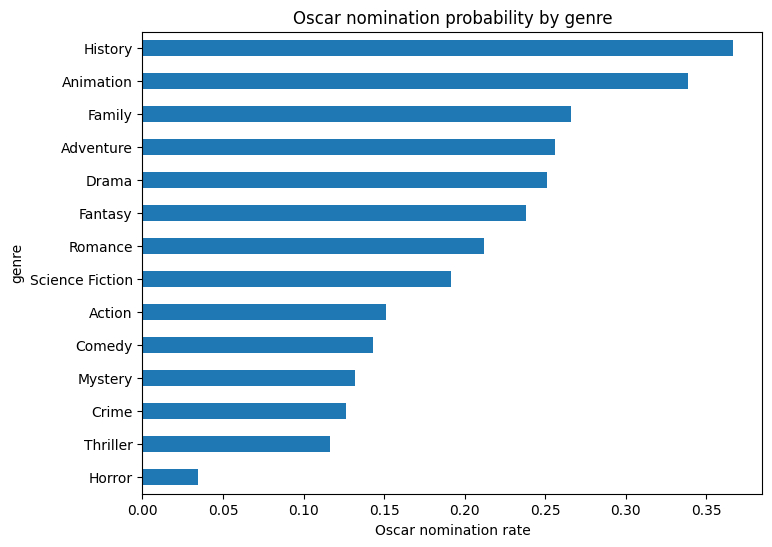

In [246]:
plt.figure(figsize=(8,6))

genre_stats["nomination_rate"].sort_values().plot(kind="barh")

plt.xlabel("Oscar nomination rate")
plt.title("Oscar nomination probability by genre")

plt.show()

Genres such as history, animation, and family show the highest nomination probabilities, while genres like horror, thriller, and crime exhibit substantially lower nomination rates.

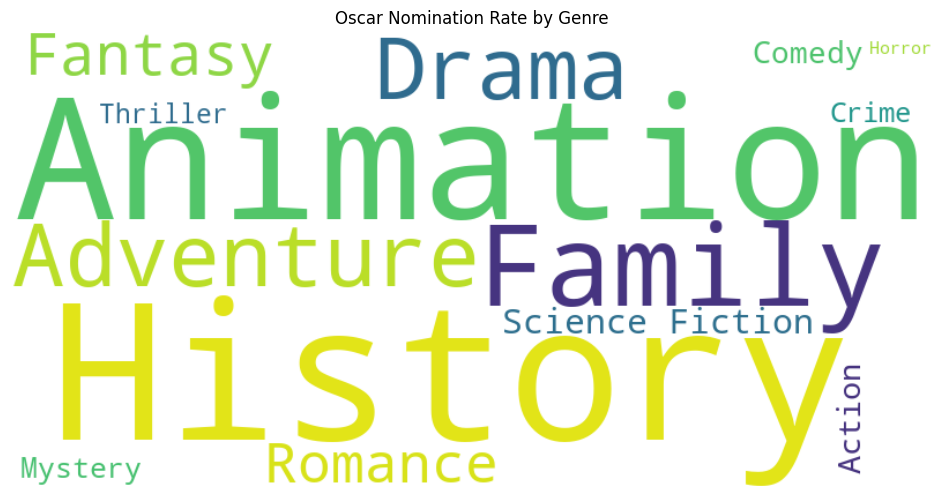

In [247]:
genre_dict = genre_stats["nomination_rate"].to_dict()

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(genre_dict)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Oscar Nomination Rate by Genre")

plt.show()

The analysis shows substantial differences in Oscar nomination rates across film genres. In the filtered sample, history films have the highest nomination rate, with about 36.6% of films receiving at least one Oscar nomination. Animation also shows a comparatively high nomination rate of around 33.9%, followed by family, adventure, and drama films, all of which have nomination rates between roughly 25% and 27%.

Genres such as fantasy, romance, and science fiction occupy a middle range, with nomination probabilities of about 19% to 24%. In contrast, action, comedy, mystery, crime, and thriller films show noticeably lower nomination rates, generally between about 11% and 15%. Horror films have by far the lowest nomination rate in the sample, at only about 3.4%.

Overall, the results suggest that genre is strongly associated with the likelihood of receiving an Academy Award nomination. It should also be noted that some genres, such as animation, may benefit from category-specific Academy Award structures, which may partly explain their relatively high nomination rates.

In [248]:
genre_multi_nom_rate = (
    df_genres.assign(multi_nom = df_genres["oscar_nominations"] >= 2)
    .groupby("genre")
    .agg(
        multi_nom_rate=("multi_nom","mean"),
        n_movies=("multi_nom","count")
    )
)

genre_multi_nom_rate = genre_multi_nom_rate[genre_multi_nom_rate["n_movies"] >= 100]

genre_multi_nom_rate.sort_values("multi_nom_rate", ascending=False)

,multi_nom_rate,n_movies
genre,,
History,0.290076,131
Drama,0.166939,1222
Romance,0.152074,434
Adventure,0.123494,664
Animation,0.118367,245
Fantasy,0.116402,378
Family,0.098630,365
Science Fiction,0.095890,438
Crime,0.081933,476


To further investigate the potential animation category effect, we examined the frequency with which films receive multiple Oscar nominations (two or more). This analysis helps determine whether the relatively high nomination rate observed for animated films reflects broader recognition across categories or is primarily driven by a single dedicated category.

The results show that history films have the highest proportion of multiple nominations, with approximately 29.0% of films receiving at least two Oscar nominations. Drama and romance films also show comparatively high rates of multiple nominations, with about 16.7% and 15.2% respectively. Adventure, animation, and fantasy films follow with nomination rates between roughly 11% and 12%.

Notably, animated films, which previously showed one of the highest overall nomination rates, have a lower rate of receiving multiple nominations compared to genres such as history, drama, and romance. This suggests that while animated films are relatively likely to receive at least one nomination, they are less frequently nominated across multiple Oscar categories.

Genres such as action, thriller, mystery, and comedy show comparatively low rates of multiple nominations, generally below 8%. Horror films again display the lowest values, with only about 2% of films receiving two or more nominations.

Overall, these results support the interpretation that the relatively high nomination rate observed for animated films may partly reflect the presence of a dedicated award category rather than broader recognition across multiple Oscar categories.

In [249]:
df_analysis["budget_group"] = pd.qcut(df_analysis["budget"],5)

In [250]:
df_analysis.groupby("budget_group")["oscar_nominated"].mean()

budget_group
(0.999, 3000000.0]           0.012559
(3000000.0, 13000000.0]      0.104811
(13000000.0, 30000000.0]     0.174475
(30000000.0, 70000000.0]     0.228333
(70000000.0, 489900000.0]    0.369128
Name: oscar_nominated, dtype: float64

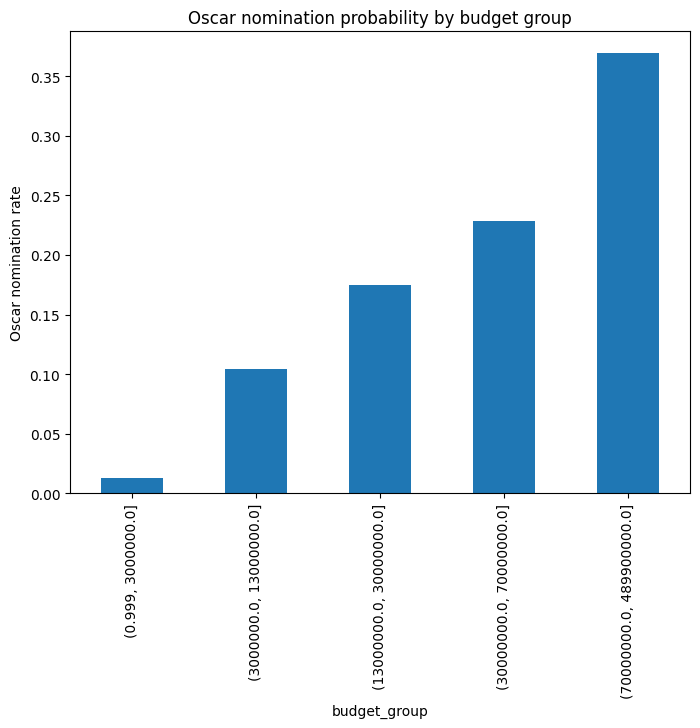

In [251]:
import matplotlib.pyplot as plt

budget_rates = df_analysis.groupby("budget_group")["oscar_nominated"].mean()

plt.figure(figsize=(8,6))
budget_rates.plot(kind="bar")

plt.ylabel("Oscar nomination rate")
plt.title("Oscar nomination probability by budget group")

plt.show()

The analysis also reveals a clear relationship between production budget and Oscar nomination rates. Films in the lowest budget group, with budgets up to about $3 million, have a nomination rate of only around 1.3%. As budgets increase, the likelihood of receiving an Oscar nomination rises steadily.

Films with budgets between roughly $3 million and $13 million show a nomination rate of about 10.5%, while films in the highest budget group, above approximately $70 million, reach a nomination rate of about 36.9%.

Overall, the results suggest that higher-budget productions are considerably more likely to receive Oscar nominations than lower-budget films.

In [252]:
# keep only genres with at least 100 films
valid_genres = genre_stats.index

# filter genre-level dataset to the selected genres
df_genres_filtered = df_genres[df_genres["genre"].isin(valid_genres)].copy()

# create budget groups
df_genres_filtered["budget_group"] = pd.qcut(df_genres_filtered["budget"], 5)

# compute nomination rate by genre and budget group
genre_budget_stats = (
    df_genres_filtered
    .groupby(["genre", "budget_group"])
    .agg(
        nomination_rate=("oscar_nominated", "mean"),
        n_movies=("oscar_nominated", "count")
    )
    .reset_index()
)

# remove very small genre-budget cells
genre_budget_stats = genre_budget_stats[genre_budget_stats["n_movies"] >= 5]

# create matrix for heatmap
genre_budget_matrix = genre_budget_stats.pivot(
    index="genre",
    columns="budget_group",
    values="nomination_rate"
)

genre_budget_matrix

budget_group,"(0.999, 5000000.0]","(5000000.0, 19000000.0]","(19000000.0, 40000000.0]","(40000000.0, 85000000.0]","(85000000.0, 489900000.0]"
genre,,,,,
Action,0.000000,0.037313,0.069892,0.150754,0.322581
Adventure,0.040816,0.078947,0.101852,0.242188,0.396040
Animation,0.057143,0.038462,0.200000,0.333333,0.586957
Comedy,0.037559,0.115942,0.126638,0.190751,0.347826
Crime,0.020202,0.084906,0.149606,0.169811,0.315789
Drama,0.066282,0.224615,0.315603,0.405405,0.566265
Family,0.048780,0.040000,0.112903,0.269663,0.504065
Fantasy,0.024390,0.054545,0.144928,0.301205,0.392308
History,0.000000,0.193548,0.513514,0.666667,0.473684


When considering both genre and budget simultaneously, the results show that higher production budgets are generally associated with a higher likelihood of receiving an Oscar nomination across most genres. In many genres, nomination rates are very low in the smallest budget group and increase noticeably in the higher budget groups.

This pattern is especially pronounced for drama, history, romance, and animation films. For example, drama increases from about 6.6% in the lowest budget group to roughly 56.6% in the highest budget group. History films also show a very strong increase, reaching nomination rates above 47% in the largest budget category. Romance and animation likewise display comparatively high nomination probabilities among higher-budget productions.

By contrast, genres such as horror, thriller, action, and comedy tend to remain at lower nomination levels overall, even though they also show some increase with larger budgets. Horror, in particular, remains one of the weakest genres in terms of nomination probability across nearly all budget groups.

Overall, the results suggest that both genre and production budget are related to Oscar nomination likelihood. Higher budgets appear to improve nomination chances in many genres, but the strength of this relationship differs substantially across genre categories. However, some genre-budget groups may contain comparatively few films, so these subgroup results should be interpreted with caution.

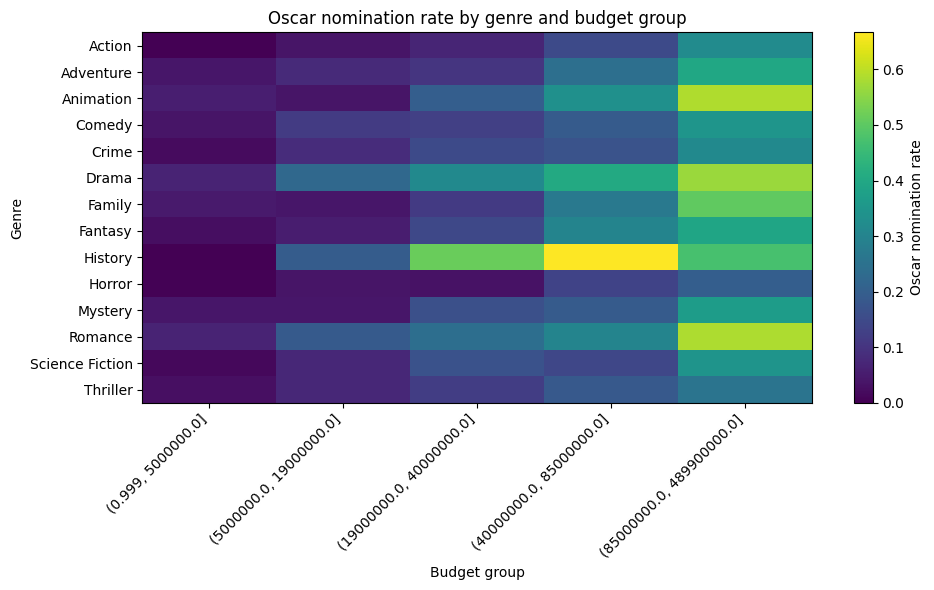

In [263]:
plt.figure(figsize=(10,6))

plt.imshow(genre_budget_matrix, aspect="auto", cmap="viridis")

plt.colorbar(label="Oscar nomination rate")

plt.xticks(
    range(len(genre_budget_matrix.columns)),
    genre_budget_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(genre_budget_matrix.index)),
    genre_budget_matrix.index
)

plt.title("Oscar nomination rate by genre and budget group")
plt.xlabel("Budget group")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

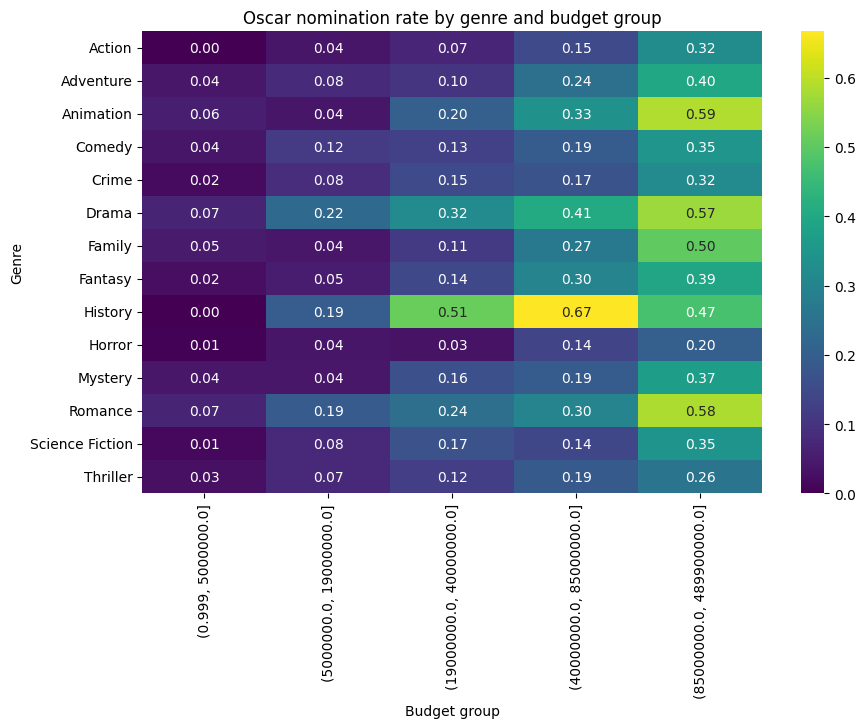

In [264]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    genre_budget_matrix,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

plt.title("Oscar nomination rate by genre and budget group")
plt.xlabel("Budget group")
plt.ylabel("Genre")

plt.show()